In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.auto import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Check if CUDA is available and set the default device to GPU if it is
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"

In [3]:
from torch.utils.data import DataLoader
from plant_dataset import PlantDataset 
if 0:
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406, 0.5], std=[0.229, 0.224, 0.225, 0.5])
    ])
else:
    transform = transforms.Compose([
        #transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5, 0.5])
        #transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5,  0.5])
    ])


image_size = 448

from plant_tokenizer import PAD_token

import pickle
# Check if the .plk file exists
dataset_dir = "../data/generated_dataset_Sep22_black"
saved_train_dataset_name = os.path.join(dataset_dir,"train_dataset.pkl")
saved_val_dataset_name = os.path.join(dataset_dir,"val_dataset.pkl")
if os.path.exists(saved_train_dataset_name):
    if os.path.exists(saved_train_dataset_name):
        print("Loading plant dataset from .pkl file")
        with open(saved_train_dataset_name, "rb") as f:
            train_dataset = pickle.load(f)
        with open(saved_val_dataset_name, "rb") as f:
            val_dataset = pickle.load(f)
else:
    preload = False

    train_dataset = PlantDataset(dataset_dir, plot=["000", "001", "002",], 
                                 transform=transform, use_depth=True, preload=preload,image_size=image_size)
    #train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000"], transform=transform)
    val_dataset = PlantDataset(dataset_dir, plot=["003"], 
                               transform=transform, use_depth=True, preload=preload,image_size=image_size)

    if preload:
        with open(saved_train_dataset_name, "wb") as f:
            pickle.dump(train_dataset, f)
        with open(saved_val_dataset_name, "wb") as f:
            pickle.dump(val_dataset, f)

Total 4831 images and plant strings loaded
Total 1585 images and plant strings loaded


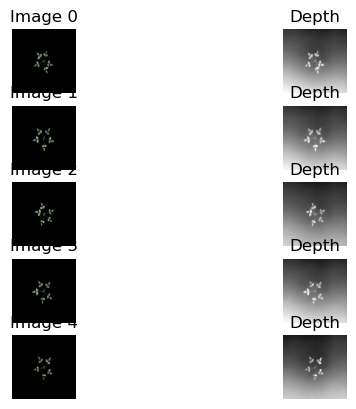

In [4]:
# Show some images
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000", "001", "002", "003"], transform=transform,dry_run=True,use_depth=False)

import cv2
n = 5
for i in range(n):
    #image, vecs, _ = train_dataset[-i-1]
    image, vecs, _ = train_dataset[i]
    image = image.permute(1, 2, 0)
    image_rgb = image[:, :, :3]
    img = cv2.normalize(np.array(image_rgb.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(img)
    plt.title(f"Image {i}")
    plt.axis('off')

    if train_dataset.use_depth:
        image_depth = image[:, :, 3]
        img = cv2.normalize(np.array(image_depth.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        plt.subplot(5, 2, 2*i+2)
        plt.imshow(img, cmap='gray')
        plt.title("Depth")
        plt.axis('off')

In [5]:
from models.model import ImageToSequenceTransformer


# Initialize model
num_layers =  3 # Default 6
num_heads = 4   # Default 8 
seq_dim = 43 # 43개의 토큰 
seq_embedding_dim = 64 # 
param_dim = 5 + 4 + 3 + 4 # 5 for shoot, 4 for the internode, 3 for the petiole, 4 for the leaf
param_embedding_dim = 64

model = ImageToSequenceTransformer(seq_embedding_dim=seq_embedding_dim, 
                                   param_embedding_dim=param_embedding_dim,
                                   num_layers=num_layers, num_heads=num_heads, 
                                   num_tokens=seq_dim, num_params=param_dim,
                                   decoder_only=True,
                                   use_depth=True,
                                   image_size=image_size)

# Test
if 0:
    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    for _,_,_ in train_dataloader:
        break
# Test model
if 0:
    image_paths, vectors, lengths = next(iter(train_dataloader))
    output = model(image_paths, vectors)
model = model.to(device)
#print(model)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
labes_loss_fn = nn.CrossEntropyLoss()

num_epochs = 20
model.to(device)

ImageToSequenceTransformer(
  (cnn): CNN_ViT(
    (model): ViTModel(
      (embeddings): ViTEmbeddings(
        (patch_embeddings): ViTPatchEmbeddings(
          (projection): Conv2d(4, 768, kernel_size=(16, 16), stride=(16, 16))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): ViTEncoder(
        (layer): ModuleList(
          (0-11): 12 x ViTLayer(
            (attention): ViTSdpaAttention(
              (attention): ViTSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): ViTSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
           

In [6]:
def collate_fn(batch):
    images, vectors, lengths = zip(*batch)
    max_length = max(lengths)
    # Check if the vectors are 1 dimensional
    if len(vectors[0].shape) == 1:
        vectors_padded = np.ones((len(vectors), max_length), dtype=int) * PAD_token
    else:
        # vectors_padded = np.ones((len(vectors), max_length, 1+5+3+2+4)) * PAD_token
        vectors_padded = np.ones((len(vectors), max_length, 1+5+4+3+4)) * PAD_token # Bacth samples are padded with PAD_token
    
        # Should not reset the param space PAD_token because of the masked loss
        if 0:
            # Reset param space
            vectors_padded[:,:,1:] = 0
        
    for i, vector in enumerate(vectors):
        end = lengths[i]
        vectors_padded[i, :end] = vector
    images = torch.stack(images)
    vectors_padded = torch.tensor(vectors_padded,dtype=torch.float32)
    return images, vectors_padded, lengths

if 1:
    train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn, num_workers=4)
    val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn, num_workers=4)
else:
    # For debugging, set num_workers to 0
    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

In [7]:
train_loss_list, validation_loss_list = [], []
pretrained = False
model_save_path = '../models/checkpoints/Image2PlantArchitecture_448_20240924.pth'
if pretrained:
    model.load_state_dict(torch.load(model_save_path))

In [8]:
import torch
from torch.optim import Optimizer
from torch.optim.lr_scheduler import _LRScheduler
from models.model import get_tgt_mask, create_pad_mask
if 0:
    opt = torch.optim.SGD(model.parameters(), lr=0.01)
else:
    opt = torch.optim.Adam(model.parameters(), 
                           betas = (0.9, 0.98),
                           lr=1e-3)
if 0:
    labes_loss_fn = nn.CrossEntropyLoss()
else:
    labes_loss_fn = nn.CrossEntropyLoss(ignore_index = PAD_token,
                        label_smoothing = 0.0)
    
if 1:
    params_loss_fn = nn.MSELoss(reduction='none') # L2 Loss
    #params_loss_fn = nn.MSELoss() # L2 Loss

alpha = 1.0

# https://kikaben.com/transformers-training-details/
# Learning rate caculation: step_num starts with 1
def calc_lr(step, dim_embed, warmup_steps):
    return dim_embed**(-0.5) * min(step**(-0.5), \
                                   step * warmup_steps**(-1.5))



class Scheduler(_LRScheduler):
    def __init__(self, 
                 optimizer: Optimizer,
                 dim_embed: int,
                 warmup_steps: int,
                 last_epoch: int=-1,
                 verbose: bool=False) -> None:

        self.dim_embed = dim_embed
        self.warmup_steps = warmup_steps
        self.num_param_groups = len(optimizer.param_groups)

        super().__init__(optimizer, last_epoch, verbose)
        
    def get_lr(self) -> float:
        lr = calc_lr(self._step_count, self.dim_embed, self.warmup_steps)
        return [lr] * self.num_param_groups


def calc_lr(step, dim_embed, warmup_steps):
    return dim_embed**(-0.5) * min(step**(-0.5), step * warmup_steps**(-1.5))

def train_loop(model, opt, label_loss_fn, param_loss_fn, dataloader):
    model.train()
    total_combined_loss = 0
    total_ce_loss = 0
    total_mse_loss = 0
    # Define progress bar
    for image, out, lengths in tqdm(dataloader):
        image = image.to(device)
        y = out.to(device)
        y_input = y[:,:-1]
        y_expected = y[:,1:]
        tgt_mask = get_tgt_mask(y_input.size(1)).to(device)
        tgt_pad_mask = create_pad_mask(y_input, PAD_token).to(device)
        outputs = model(image, y_input, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_pad_mask)
        outputs = outputs.permute(1, 2, 0)
        label = y_expected[:,:,0].long()
        values = y_expected[:,:,1:].permute(0, 2, 1)
        loss_ce = label_loss_fn(outputs[:,:seq_dim], label)
        if 0:
            loss_mse = alpha*param_loss_fn(outputs[:,seq_dim:], values)
        else:
            mask = (values == PAD_token) # See the collate_fn comment above
            loss_mse = alpha*param_loss_fn(outputs[:,seq_dim:], values)
            masked_loss = loss_mse * ~mask
            loss_mse = masked_loss.sum() / (~mask).sum()
            
        combined_loss = loss_ce + loss_mse
        opt.zero_grad()
        combined_loss.backward()
        opt.step()
        total_combined_loss += combined_loss.detach().item()
        total_ce_loss += loss_ce.detach().item()
        total_mse_loss += loss_mse.detach().item()

        # Update progress bar
        # pbar.set_description(f"Loss: {combined_loss.detach().item():.4f}, CE Loss: {loss_ce.detach().item():.4f}, MSE Loss: {loss_mse.detach().item():.4f}")
        
    return total_combined_loss / len(dataloader), total_ce_loss / len(dataloader), total_mse_loss / len(dataloader)

def validation_loop(model, label_loss_fn, param_loss_fn, dataloader):
    model.eval()
    total_combined_loss = 0
    total_ce_loss = 0
    total_mse_loss = 0
    with torch.no_grad():
        #for image, out, lengths in tqdm(dataloader):
        for image, out, lengths in (dataloader):
            image = image.to(device)
            y = out.to(device)
            y_input = y[:,:-1]
            y_expected = y[:,1:]
            tgt_mask = get_tgt_mask(y_input.size(1)).to(device)
            tgt_pad_mask = create_pad_mask(y_input, PAD_token).to(device)
            outputs = model(image, y_input, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_pad_mask)
            outputs = outputs.permute(1, 2, 0)
            label = y_expected[:,:,0].long()
            values = y_expected[:,:,1:].permute(0, 2, 1)
            loss_ce = label_loss_fn(outputs[:,:seq_dim], label)
            if 0:
                loss_mse = alpha*param_loss_fn(outputs[:,seq_dim:], values)
            else:
                mask = (values == PAD_token)
                loss_mse = alpha*param_loss_fn(outputs[:,seq_dim:], values)
                masked_loss = loss_mse * ~mask
                loss_mse = masked_loss.sum() / (~mask).sum()

            combined_loss = loss_ce + loss_mse
            total_combined_loss += combined_loss.detach().item()
            total_ce_loss += loss_ce.detach().item()
            total_mse_loss += loss_mse.detach().item()

            # Update progress bar
            # pbar.set_description(f"Loss: {combined_loss.detach().item():.4f}, CE Loss: {loss_ce.detach().item():.4f}, MSE Loss: {loss_mse.detach().item():.4f}")
 
    return total_combined_loss / len(dataloader), total_ce_loss / len(dataloader), total_mse_loss / len(dataloader)

from torch.optim.lr_scheduler import ReduceLROnPlateau

def fit(model, opt, loss_fn_cse, loss_fn_mse, train_dataloader, val_dataloader, epochs, model_save_path, patience=5):
    best_validation_loss = float('inf')
    epochs_no_improve = 0  # Counter for epochs with no improvement
    if 1:
        scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=patience)
        # UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.  
    else:
        scheduler = Scheduler(opt, dim_embed=seq_embedding_dim+param_embedding_dim, warmup_steps=1000)


    print("Training and validating model")
    for epoch in range(epochs):
        print("-"*25, f"Epoch {epoch + 1}","-"*25)
        train_loss, train_cse_loss, train_mse_loss = train_loop(model, opt, loss_fn_cse, loss_fn_mse, train_dataloader)
        train_loss_list.append([train_loss, train_cse_loss, train_mse_loss])
        print(f"Training total loss: {train_loss:.4f}, CE loss: {train_cse_loss:.4f}, MSE loss: {train_mse_loss:.4f}")
        
        validation_loss, val_cse_loss, val_mse_loss = validation_loop(model, loss_fn_cse, loss_fn_mse, val_dataloader)
        validation_loss_list.append([validation_loss, val_cse_loss, val_mse_loss])
        print(f"Validation total loss: {validation_loss:.4f}, CE loss: {val_cse_loss:.4f}, MSE loss: {val_mse_loss:.4f}")

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            print(f"Saving best model with validation loss: {best_validation_loss:.4f}")
            torch.save(model.state_dict(), model_save_path)
            epochs_no_improve = 0  # Reset counter
        else:
            epochs_no_improve += 1  # Increment counter
            print(f"No improvement in validation loss for {epochs_no_improve} epochs.")

        if epochs_no_improve >= 2*patience:
            print(f"Early stopping triggered after no improvement in validation loss for {epochs_no_improve} epochs.")
            break  # Early stopping
        
        if 1:
            scheduler.step(validation_loss)  # Adjust the learning rate based on validation loss
        else:
            # learning rate scheduler
            if scheduler is not None:
                scheduler.step()
        print()

    return train_loss_list, validation_loss_list



In [ ]:
train_loss_list, validation_loss_list = fit(model, opt, labes_loss_fn, params_loss_fn, train_dataloader, val_dataloader, 200, model_save_path)

Training and validating model
------------------------- Epoch 1 -------------------------


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 302/302 [04:08<00:00,  1.21it/s]

Training total loss: 0.6675, CE loss: 0.4064, MSE loss: 0.2611


Validation total loss: 0.3369, CE loss: 0.2276, MSE loss: 0.1093
Saving best model with validation loss: 0.3369

------------------------- Epoch 2 -------------------------


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 302/302 [04:09<00:00,  1.21it/s]

...

Validation total loss: 0.1192, CE loss: 0.0679, MSE loss: 0.0512
Saving best model with validation loss: 0.1192

------------------------- Epoch 33 -------------------------


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 302/302 [04:11<00:00,  1.20it/s]

Training total loss: 0.1395, CE loss: 0.0822, MSE loss: 0.0574


Validation total loss: 0.1282, CE loss: 0.0771, MSE loss: 0.0510
No improvement in validation loss for 1 epochs.

------------------------- Epoch 34 -------------------------


  2%|██▍                                                                                                      | 7/302 [00:06<04:17,  1.14it/s]

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_loss_list, label = ["Train loss", "Train CE loss", "Train MSE loss"])
plt.plot(validation_loss_list, label = ["Val loss", "Val CE loss", "Val MSE loss"])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [ ]:
import torch.nn.functional as F
from plant_tokenizer import params_SOS_token_padded, SOS_token, EOS_token

def train_gen_loop(model, opt, label_loss_fn, param_loss_fn, dataloader):
    model.train()
    total_combined_loss = []
    total_ce_loss = []
    total_mse_loss = []
    # Define progress bar
    for image, out, lengths in (dataloader):

        with torch.no_grad():
            image = image.to(device)
            y = out.to(device)
            y_input = y[:,:-1]
            y_expected = y[:,1:]
            
            max_length = 2048
            y_input = torch.tensor(params_SOS_token_padded, dtype=torch.float32)
            # Create an emtpy tensor to store the predicted probabilities
            y_input = y_input.unsqueeze(0).unsqueeze(0)
            y_input = y_input.to(device)


        for i in tqdm(range(lengths[0]-1)):
            with torch.no_grad():
                tgt_mask = get_tgt_mask(y_input.size(1)).to(device)

            try:
                pred = model(image, y_input, tgt_mask)
            except Exception as e:
                print(e)
                print(f"Error in {i} iteration")
                break
            label_p = pred[:,:,:seq_dim].squeeze(0)
            label_p_list = pred[:,:,:seq_dim].squeeze(1)
            label = label_p.topk(1)[1].view(-1)[-1].item()  # num with highest probability
            estimated_params = pred[:,:,seq_dim:]

            # Stop if model predicts end of sentencplant_structure_vit_transformer_withpsudodepth_paramEste
            # if label == EOS_token or label == PAD_token:


            # Calculate loss
            # Make next tensor using label and params
            with torch.no_grad():
                next_item = torch.cat((torch.tensor([[label]], dtype=torch.float32, device=device), estimated_params[-1]), dim=1).unsqueeze(0)

                # Concatenate previous input with predicted best word
                y_input = torch.cat((y_input, next_item), dim=1)
        
            # Check the len(pred) and len(label)
            true_labels = y_expected[:,:,:1].squeeze().long()
            # If the length is different, then padd the shorter one with zeros
            
            if len(label_p_list) < len(true_labels):
                true_labels = true_labels[:len(label_p_list)]
            elif len(label_p_list) > len(true_labels):
                # Add padding to the true_labels
                true_labels = torch.cat((true_labels, torch.ones(len(label_p_list) - len(true_labels), 
                                                                 dtype=torch.long,device=device)*PAD_token))

            loss_ce = label_loss_fn(label_p_list,true_labels)

            expected_params = y_expected[:,:,1:].squeeze(0)
            estimated_params = pred[:,:,seq_dim:].squeeze(1)
            if len(estimated_params) < len(expected_params):
                expected_params = expected_params[:len(estimated_params)]
            elif len(estimated_params) > len(expected_params):
                # Add padding to the true_labels
                expected_params = torch.cat((expected_params, torch.zeros((len(estimated_params) - len(expected_params),16),
                                                                          dtype=torch.float32,device=device)))

            loss_mse = alpha*F.mse_loss(estimated_params, expected_params)
            combined_loss = loss_ce + loss_mse
            opt.zero_grad()
            combined_loss.backward()
            opt.step()
            total_combined_loss.append(combined_loss.detach().item())
            total_ce_loss.append(loss_ce.detach().item())
            total_mse_loss.append(loss_mse.detach().item())

            if label == EOS_token:
                break

        break

    return sum(total_combined_loss) / len(total_combined_loss), sum(total_ce_loss) / len(total_combined_loss), sum(total_mse_loss) / len(total_mse_loss)


def fit_gen(model, opt, loss_fn_cse, loss_fn_mse, train_dataloader, val_dataloader, epochs, model_save_path, patience=5):
    best_validation_loss = float('inf')
    epochs_no_improve = 0  # Counter for epochs with no improvement
    if 1:
        scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=patience, verbose=True)
    else:
        scheduler = Scheduler(opt, dim_embed=seq_embedding_dim+param_embedding_dim, warmup_steps=1000)


    print("Training and validating model")
    for epoch in range(epochs):
        print("-"*25, f"Epoch {epoch + 1}","-"*25)
        train_loss, train_cse_loss, train_mse_loss = train_gen_loop(model, opt, loss_fn_cse, loss_fn_mse, train_dataloader)
        train_loss_list.append([train_loss, train_cse_loss, train_mse_loss])
        print(f"Training total loss: {train_loss:.4f}, CE loss: {train_cse_loss:.4f}, MSE loss: {train_mse_loss:.4f}")
        
        validation_loss, val_cse_loss, val_mse_loss = validation_loop(model, loss_fn_cse, loss_fn_mse, val_dataloader)
        validation_loss_list.append([validation_loss, val_cse_loss, val_mse_loss])
        print(f"Validation total loss: {validation_loss:.4f}, CE loss: {val_cse_loss:.4f}, MSE loss: {val_mse_loss:.4f}")

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            print(f"Saving best model with validation loss: {best_validation_loss:.4f}")
            torch.save(model.state_dict(), model_save_path_tuned)
            epochs_no_improve = 0  # Reset counter
        else:
            epochs_no_improve += 1  # Increment counter
            print(f"No improvement in validation loss for {epochs_no_improve} epochs.")

        if epochs_no_improve >= 2*patience:
            print(f"Early stopping triggered after no improvement in validation loss for {epochs_no_improve} epochs.")
            break  # Early stopping
        
        if 1:
            scheduler.step(validation_loss)  # Adjust the learning rate based on validation loss
        else:
            # learning rate scheduler
            if scheduler is not None:
                scheduler.step()
        print()

    return train_loss_list, validation_loss_list

# Disable the autoregressive model training for now.
if 0:
    # Load the best model
    model.load_state_dict(torch.load(model_save_path))

    model_save_path_tuned = '../models/checkpoints/Image2PlantArchitecture_20240923_tuned.pth'
    train_loss_list, validation_loss_list = [], []
    train_dataloader_gen = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
    val_dataloader_gen = DataLoader(val_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn, num_workers=4)

    # Use smaller lr?
    opt = torch.optim.Adam(model.parameters(), 
                            betas = (0.9, 0.98),
                            lr=1e-4)

    train_loss_list, validation_loss_list = fit_gen(model, opt, labes_loss_fn, params_loss_fn, train_dataloader_gen, val_dataloader_gen, 200, model_save_path)